# Thompson Sampling Algorithm

### Scenario: Advertising Campaign with 10,000 users and 10 ads
- Imagine you are running an online advertising campaign for 10 different ads (Ad 1 to Ad 10). Your goal is to determine which ad performs best (i.e., gets the most clicks) and display it more often to maximize engagement.

### How the Thompson Sampling Algorithm Works

1. #### Objective:
    - Similar to the Upper Confidence Bound (UCB) algorithm, Thompson Sampling balances two objectives:
        1. Exploration: Randomly select ads to gather information about their performance.

        2. Exploitation: Focus on ads that are likely (probabilistic) to perform well based on the information gathered.

2. #### Rounds:
    - Each round represents one user visiting the website or app.

    - The algorithm selects one ad to show based on the probability of it being the best-performing ad, using a probability distribution that updates dynamically.

### Steps in Thompson Sampling

1. Initialization:
    - Start with no prior knowledge of the performance of any ad.

    - Assign a Beta (probabilistic) distribution, 𝐵𝑒𝑡𝑎(𝑎,𝑏), to each ad, where:
        - 𝑎: Number of times the ad was clicked + 1.

        - 𝑏: Number of times the ad was shown but not clicked + 1.

2. Ad Selection (Per Round):
    - For each ad, sample a random value from its Beta distribution.

    - Select the ad with the highest sampled value to display to the current user.

3. Update Distribution:
    - After the user interacts with the ad (e.g., clicks or doesn't click), update the Beta distribution for the selected ad:
        - Increase '𝑎' if the ad was clicked.

        - Increase '𝑏' if the ad was not clicked.

### Difference from Upper Confidence Bound (UCB) Algorithm:
- Thompson Sampling randomly selects an ad to show to the user based on its prior probability.

- UCB selects the ad that has the highest Upper Confidence Bound (UCB).

- Thompson Sampling selects the ad that has the highest posterior probability (probability of the ad being selected based on its prior and current data).

- It is based on Bayesian probability and confidence intervals.

- Can be more efficient than UCB for large datasets.

- Thompson Sampling can be used in combination with other algorithms to improve performance.

- Can accomodate delayed feedback (E.g., Can update after every 500, 1,000 or more rounds, instead after every round).

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pandas as pd

## Loading the dataset

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')
dataset

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,0,0,1,0,0,0,0,1,0,0
9996,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0
9998,1,0,0,0,0,0,0,1,0,0


## Implementing Thompson Sampling Algorithm

In [7]:
# N = dataset.shape[0] # 'N = number of rounds (users/user interactions) in the dataset' -> 10,000 rounds
# N = dataset.shape[0] - 5000 # Number of rounds (users/user interactions) in the dataset' -> 5,000 rounds
# N = dataset.shape[0] - 9000 # Number of rounds (users/user interactions) in the dataset' -> 1,000 rounds
N = dataset.shape[0] - 9500 # UCB cannot find the best ad in 500 rounds.
ads = dataset.shape[1] # 'ads = number of columns (ads) in the dataset'
ads_selected = [] # 'ads_selected = list to store the selected ads'
num_rewards_1 = np.zeros(ads) # 'num_rewards_1 = array to store the number of times each ad was clicked'
num_rewards_0 = np.zeros(ads) # 'num_rewards_0 = array to store the number of times each ad was not clicked but was viewed'
total_rewards = 0 # 'total_rewards = array to store the total rewards obtained'

for n in range(N):
    max_random = 0
    ad_selected_random = 0
    for i in range(ads):
        random_beta = np.random.beta(num_rewards_1[i] + 1, num_rewards_0[i] + 1)
        if random_beta > max_random:
            max_random = random_beta
            ad_selected_random = i
    ads_selected.append(ad_selected_random)
    reward = dataset.values[n, ad_selected_random]
    if reward == 1:
        num_rewards_1[ad_selected_random] += 1
    else:
        num_rewards_0[ad_selected_random] += 1
    total_rewards += reward

In [8]:
ads_selected

[9,
 0,
 1,
 9,
 2,
 6,
 0,
 9,
 2,
 4,
 3,
 5,
 6,
 7,
 1,
 8,
 2,
 4,
 7,
 3,
 8,
 2,
 5,
 7,
 7,
 7,
 7,
 7,
 3,
 8,
 7,
 6,
 5,
 7,
 7,
 8,
 8,
 3,
 7,
 7,
 0,
 8,
 7,
 7,
 7,
 8,
 7,
 4,
 7,
 0,
 5,
 7,
 3,
 1,
 8,
 8,
 7,
 6,
 7,
 7,
 2,
 7,
 7,
 1,
 9,
 4,
 7,
 7,
 7,
 9,
 6,
 2,
 8,
 0,
 7,
 7,
 4,
 2,
 9,
 7,
 6,
 0,
 7,
 3,
 4,
 8,
 1,
 6,
 7,
 6,
 7,
 5,
 7,
 5,
 7,
 7,
 7,
 6,
 9,
 6,
 6,
 4,
 5,
 7,
 7,
 7,
 7,
 6,
 0,
 7,
 7,
 5,
 7,
 4,
 7,
 7,
 1,
 8,
 7,
 1,
 6,
 1,
 1,
 0,
 1,
 4,
 1,
 4,
 6,
 7,
 4,
 2,
 4,
 1,
 1,
 8,
 6,
 9,
 4,
 7,
 1,
 4,
 4,
 1,
 1,
 4,
 6,
 3,
 4,
 1,
 6,
 4,
 9,
 4,
 0,
 1,
 4,
 1,
 1,
 1,
 4,
 6,
 1,
 3,
 7,
 7,
 7,
 6,
 1,
 4,
 1,
 4,
 7,
 1,
 4,
 6,
 1,
 8,
 1,
 1,
 1,
 1,
 1,
 6,
 6,
 1,
 4,
 5,
 4,
 2,
 8,
 1,
 9,
 6,
 6,
 4,
 4,
 1,
 9,
 1,
 4,
 4,
 6,
 4,
 4,
 4,
 2,
 5,
 0,
 4,
 4,
 0,
 0,
 0,
 6,
 4,
 4,
 4,
 2,
 2,
 6,
 6,
 0,
 0,
 6,
 0,
 4,
 4,
 7,
 3,
 6,
 2,
 4,
 6,
 3,
 4,
 6,
 7,
 4,
 0,
 6,
 3,
 0,
 6,
 4,
 2,
 8,
 2,
 6,
 0,


## Visualising the results to determine the best performing ad(s)

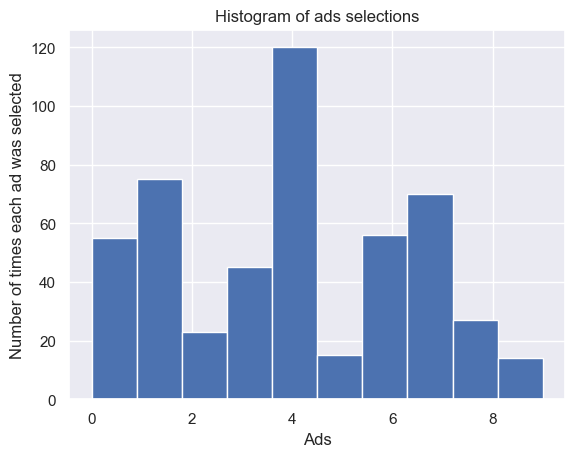

In [9]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()